*Computer Assignments: Sparse Recovery via $l_0$ and $l_1$ minimization*

**Recovery Challenge:** We have a signal $\mathbf{x}$ of 100 samples ($N = 100$) where no more than 3 of these samples are nonzero ($S \leq 3$). The location and magnitude of these nonzero samples are unknown. We have applied two different sensing matrices $\mathbf{A}$ on $\mathbf{x}$ and obtained two set of measurements $\mathbf{y} = \mathbf{A}\mathbf{x}$. The data is downloaded in the same folder as this notebook.

In [1]:
# Import necessary libraries
from itertools import combinations
import time

from scipy.io import loadmat
import numpy as np
from scipy.optimize import linprog
from matplotlib import pyplot as plt

First we need to load the sensing matrices from the .mat file.

In [ ]:
DATA_FILE = '../data/COMP5340HW1.mat'

In [3]:
def load_data(data_file):
    """ 
    Load the data from the .mat file and return it as a dictionary.
    """
    data = loadmat(data_file)

    Af = data['Af']
    Ar = data['Ar']
    yf = data['yf']
    yr = data['yr']
    
    return {
        'Af': Af,
        'Ar': Ar,
        'yf': yf,
        'yr': yr
    }

data = load_data(DATA_FILE)
print("Data loaded successfully. The shapes of the matrices are:")
print(f" Af: {data['Af'].shape}, Ar: {data['Ar'].shape}, yf: {data['yf'].shape}, yr: {data['yr'].shape}")

Data loaded successfully. The shapes of the matrices are:
 Af: (25, 100), Ar: (25, 100), yf: (25, 1), yr: (25, 1)


## Part 1
Recover $\mathbf{x}$ using $l_0$ minimization via exhaustive search.

In [4]:
def check_solution(A, x, y):
    """
    Check if the solution x satisfies Ax = y.
    """
    return np.allclose(A @ x, y.ravel())
    
def solve_l0_exhaustive(A, y):
    """
    Solve the l0 minimization problem: min ||x||_0 subject to Ax = y.
    """
    # x is sparse with less than 3 non-zero entries
    # we can use a brute-force approach to find the solution
    M, N = A.shape
    # Check 1 non-zero entry, then 2, then 3
    solutions = []
    for k in range(1, 4):
        for indices in combinations(range(N), k):
            try:
                x = np.zeros(N)
                A_sub = A[:, indices]
                x_sub = np.linalg.lstsq(A_sub, y.ravel(), rcond=None)[0]
                x[list(indices)] = x_sub
                if check_solution(A, x, y):
                    solutions.append(x)
            except np.linalg.LinAlgError:
                # Skip singular matrices
                continue
    return solutions

In [5]:
x_l0 = solve_l0_exhaustive(data['Af'], data['yf'])
solution_found = None
for sol in x_l0:
    if check_solution(data['Ar'], sol, data['yr'].ravel()):
        print("Found a valid solution using l0 minimization: \n %s" % sol)
        solution_found = sol
if solution_found is None:
    print("No valid solution found using l0 minimization.")

Found a valid solution using l0 minimization: 
 [ 0.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  0.  0.
  0.  0.  0.  0.  0.  0.  0. 40.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


## Part 2
Recover $\mathbf{x}$ using $l_1$ minimization via linear programming.

In [6]:
def solve_l1_linear_programming(A, y):
    """
    Solve the l1 minimization problem: min ||x||_1 subject to Ax = y.
    This can be implemented using linear programming or convex optimization libraries.
    For simplicity, we will not implement this here, but it can be done using libraries like CVXPY.
    """
    M, N = A.shape

    # L1 norm can be represented as a linear program by introducing auxiliary variables u, v
    # x = u - v, where u >= 0, v >= 0, and we minimize sum(u + v)

    # Constraints: A(u - v) = y, u >= 0, v >= 0
    A_eq = np.hstack((A, -A))  # Combine A for u and -A for v
    b_eq = y.ravel()
    
    # Objectives function coefficients for the linear program
    # Here we are minimizing the l1 norm
    c = np.ones(2*N)

    # Solve the linear program using scipy's linprog
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')

    if res.success:
        u = res.x[:N]
        v = res.x[N:]
        x = u - v
        return x
    else:
        print("Linear programming failed to find a solution: %s" % res.message)
        return None

In [7]:
x_l1 = solve_l1_linear_programming(data['Af'], data['yf'])
if x_l1 is not None and check_solution(data['Ar'], x_l1, data['yr'].ravel()):
    print("Found a valid solution using l1 minimization: \n", x_l1)
else:
    print("No valid solution found using l1 minimization.") 

Found a valid solution using l1 minimization: 
 [ 0.00000000e+00  1.71587949e-14  5.00000000e+00  0.00000000e+00
 -5.55518686e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  3.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  4.00000000e+01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.69772448e-14 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -6.62690231e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -7.46832811e-14  0.00000000e+00  0.000000

We can see that there are very small difference between the vector recovered by $l_0$ minimization and $l_1$ minimization. So small they are essentially the same. 

Now we rerun and time the 2 strategies.

In [8]:
def timing_wrapper(func):
    """
    A simple timing wrapper to measure the execution time of a function.
    """
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print("Execution time for %s: %f seconds" % (func.__name__, end_time - start_time))
        return result
    return wrapper

In [9]:
print("\nTiming the l0 minimization solver:")
x_l0_timed = timing_wrapper(solve_l0_exhaustive)(data['Af'], data['yf'])

print("\nTiming the l1 minimization solver:")
x_l1_timed = timing_wrapper(solve_l1_linear_programming)(data['Af'], data['yf'])


Timing the l0 minimization solver:
Execution time for solve_l0_exhaustive: 14.534065 seconds

Timing the l1 minimization solver:
Execution time for solve_l1_linear_programming: 0.007886 seconds


We can see that the $l_1$ minimization via linear programming is much faster.

## Part 3

We see that both methods arrive at similar results. 

Both matrices successfully recovered the signal for sparsity $S=3$.

Taking a closer look at the recovered vectors. For that we will use a stem plot.

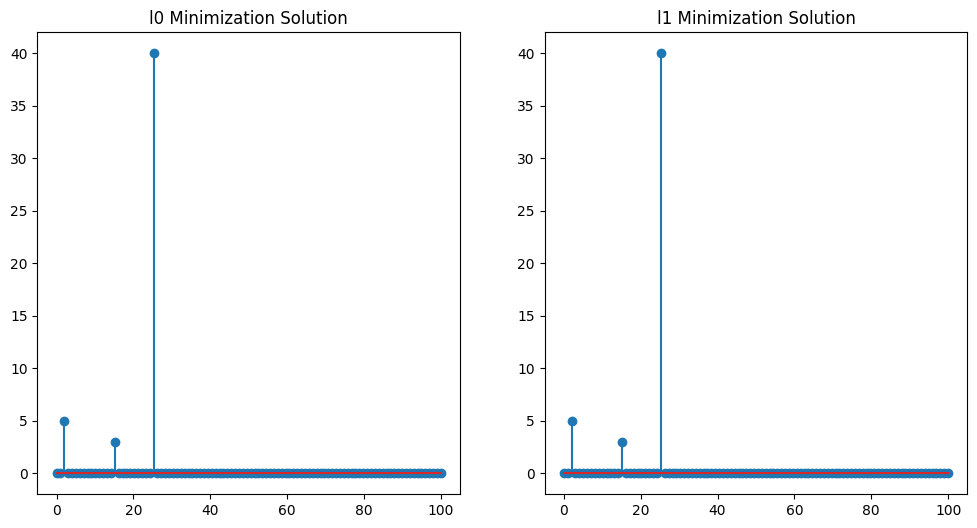

In [ ]:
# Plot the solutions for visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.stem(np.linspace(0, len(x_l0[0]), len(x_l0[0])), x_l0[0])
plt.title('l0 Minimization Solution')
plt.subplot(1, 2, 2)
plt.stem(np.linspace(0, len(x_l1), len(x_l1)), x_l1)
plt.title('l1 Minimization Solution')
plt.show()

Let's take a closer look at the 2 sensing matrices.

In [10]:
# Print Af
A_f = np.array2string(data['Af'], precision=3, suppress_small=True)
print(f"Af shape: {data['Af'].shape}")
print("Af:\n%s" % data['Af'])


# Print Ar
A_r = np.array2string(data['Ar'], precision=3, suppress_small=True)
print(f"Ar shape: {data['Ar'].shape}")
print("Ar:\n%s" % data['Ar'])

Af shape: (25, 100)
Af:
[[ 0.1297901   0.04790478 -0.06420395 ... -0.06420395  0.04790478
   0.1297901 ]
 [ 0.13801547  0.11174479  0.06420395 ...  0.06420395  0.11174479
   0.13801547]
 [ 0.06813026 -0.14114229  0.08312539 ...  0.08312539 -0.14114229
   0.06813026]
 ...
 [ 0.02431445 -0.07006844  0.10753764 ... -0.10753764  0.07006844
  -0.02431445]
 [ 0.1389164   0.119406    0.08312539 ...  0.08312539  0.119406
   0.1389164 ]
 [ 0.07389246 -0.1409854   0.05411961 ... -0.05411961  0.1409854
  -0.07389246]]
Ar shape: (25, 100)
Ar:
[[-0.0490093   0.20277054 -0.04110997 ... -0.03738695  0.0333424
  -0.0308424 ]
 [-0.0099044  -0.2545088  -0.0008712  ... -0.17659126  0.02771566
  -0.06948951]
 [-0.08056281  0.08363532  0.05948011 ... -0.09210912  0.09703726
   0.10988572]
 ...
 [ 0.07543838  0.03885239 -0.18244193 ...  0.00828508  0.06346245
   0.02502656]
 [-0.02039766  0.03095695  0.00920365 ... -0.01559175  0.11994366
   0.34130846]
 [ 0.22503755  0.17125245 -0.13211823 ... -0.25508527 

At first glance, there is not much difference between the matrices.

We can try plotting the two matrices.

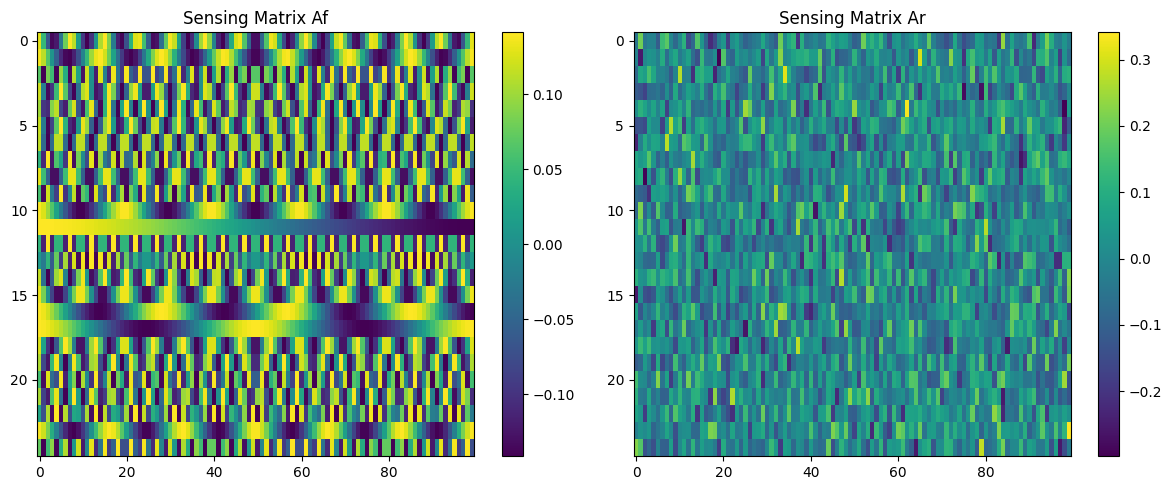

In [11]:
# Plot the 2 matrices as heatmaps
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Sensing Matrix Af")
plt.imshow(data['Af'], aspect='auto', cmap='viridis')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("Sensing Matrix Ar")
plt.imshow(data['Ar'], aspect='auto', cmap='viridis')
plt.colorbar()
plt.tight_layout()

It looks like the rows of sensing matrix $\mathbf{A_f}$ are sine waves of different frequency and the values of items in sensing matrix $\mathbf{A_r}$ are random.

## Part 4

Testing for different sparsity level.

Since $l_0$ minimization takes a long time to run. We will not test it as the computation time will increase factorially.

In [12]:
def generate_and_test(A, S_level, seed=42):
    N = A.shape[1]
    np.random.seed(seed)
    # 1. Create a sparse x
    x_true = np.zeros(N)
    indices = np.random.choice(N, S_level, replace=False)
    x_true[indices] = np.random.uniform(1, 50, S_level) # Random magnitudes
    
    # 2. Generate measurements
    y = A @ x_true
    
    # 3. Recover with L1 (LP)
    x_rec = solve_l1_linear_programming(A, y)
    
    # 4. Check error
    error = np.linalg.norm(x_true - x_rec)
    return error

In [13]:
for S in range(3, 11):
    error = generate_and_test(data['Af'], S)
    print(f"Sparsity level: {S}, Recovery error: {error}")

Sparsity level: 3, Recovery error: 8.194551550271381e-13
Sparsity level: 4, Recovery error: 6.065090501934197e-13
Sparsity level: 5, Recovery error: 1.4552623086708526e-12
Sparsity level: 6, Recovery error: 2.20481027851958e-12
Sparsity level: 7, Recovery error: 3.394900855185048e-12
Sparsity level: 8, Recovery error: 110.06198439462142
Sparsity level: 9, Recovery error: 110.37834491485637
Sparsity level: 10, Recovery error: 108.80729122405927


To see how the recovery error is affected by the sparsity level, we can perform the experiment many times and calculate the average error for each sparsity level.

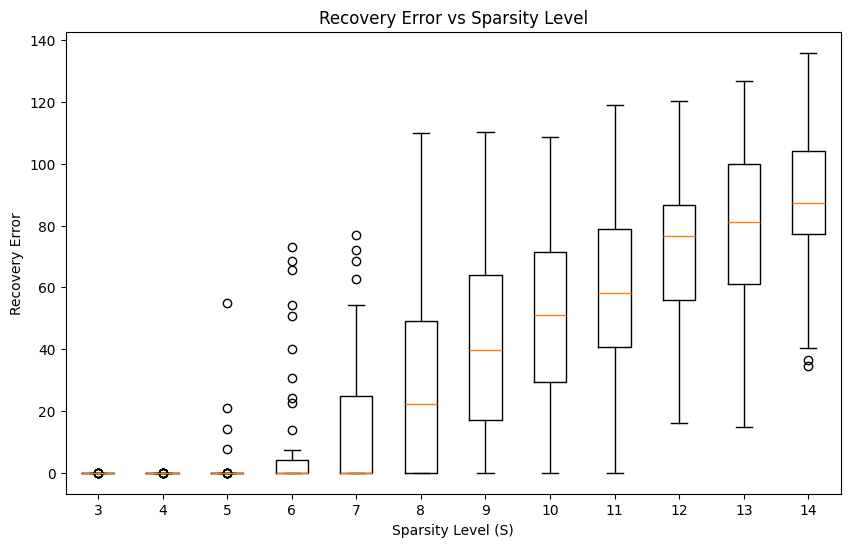

In [16]:
errors = {}
for S in range(3, 15):
    for seed in range(50):
        error = generate_and_test(data['Af'], S, seed)
        errors[S] = errors.get(S, []) + [error]

# Plot boxplot of error vs sparsity level
plt.figure(figsize=(10, 6))
plt.boxplot([errors[S] for S in errors], positions=range(3, 15))
plt.xlabel("Sparsity Level (S)")
plt.ylabel("Recovery Error")
plt.title("Recovery Error vs Sparsity Level")
plt.show()

It can be observed that the higher the sparsity level, the higher the chances that we get a high recovery errors. It is also worth noted that the error increases significantly at sparsity level 8.